In [8]:
import tensorflow
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from keras import utils,Sequential
from keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import (
    RandomFlip,
    RandomRotation,
    RandomZoom,
    RandomContrast,
    Lambda,
    GlobalAveragePooling2D,
    Dense,
    BatchNormalization,
    Dropout
)
from keras.callbacks import EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.optimizers import AdamW

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fahadullaha/facial-emotion-recognition-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/fahadullaha/facial-emotion-recognition-dataset


In [4]:
train_data=utils.image_dataset_from_directory(
    directory='/kaggle/input/datasets/fahadullaha/facial-emotion-recognition-dataset/processed_data',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256),
    seed=42,
    shuffle=True,
    validation_split=0.2,
    subset='training'
)

validation=utils.image_dataset_from_directory(
    directory='/kaggle/input/datasets/fahadullaha/facial-emotion-recognition-dataset/processed_data',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256),
    shuffle=False,
    validation_split=0.2,
    subset='validation'
)

classes=train_data.class_names
classes

Found 49779 files belonging to 7 classes.
Using 39824 files for training.
Found 49779 files belonging to 7 classes.
Using 9955 files for validation.


['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

In [5]:
print("Training batches:", len(train_data))
print("Validation batches:", len(validation))
print("Classes detected:", len(train_data.class_names))
print("Class indices:",
      {name: i for i, name in enumerate(train_data.class_names)})

Training batches: 1245
Validation batches: 312
Classes detected: 7
Class indices: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


tf.Tensor([4 6 3 0 6 6 4 3 3 0 2 4 4 2 4 6 2 6 5 6 3 5 1 6 3 4 3 0 3 3 2 3], shape=(32,), dtype=int32)


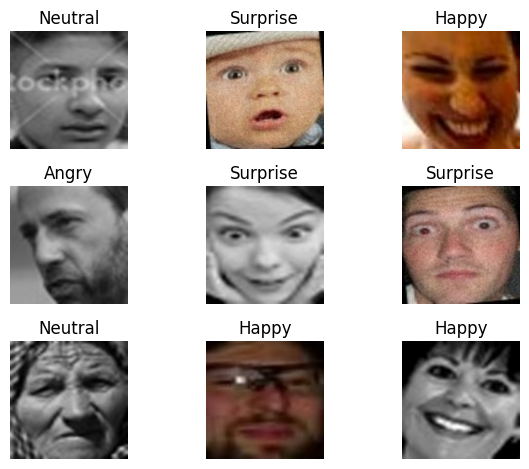

In [6]:
images,labels=next(iter(train_data))

print(labels[:])

expression={
    0:'Angry',
    1:'Disgust',
    2:'Fear',
    3:'Happy',
    4:'Neutral',
    5:'Sad',
    6:'Surprise'
}

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype('uint8'))
    plt.title(expression[int(labels[i])])
    plt.axis('off')

plt.tight_layout()
plt.show()
    

In [20]:
foundational_model=ResNet50(
    weights='imagenet',
    input_shape=(256,256,3),
    include_top=False
)

for layer in foundational_model.layers:
    layer.trainable=False

data_augmentation=Sequential([
    RandomFlip('horizontal'),
    RandomRotation(0.1),
    RandomZoom(0.1),
])

for layer in foundational_model.layers[-40:]:
    layer.trainable=True


model=Sequential([
    data_augmentation,
    # Rescaling(1./255),   ##didnt worked since resnet50 was preprocessed differently hence used preprocess_input which is the same preprocessing of Res
    Lambda(preprocess_input),
    foundational_model,
    GlobalAveragePooling2D(),

    Dense(512,activation='relu'),
    BatchNormalization(),
    Dropout(0.1),

    Dense(256,activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128,activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(7,activation='softmax')
])

In [21]:
model.compile(
    # optimizer=AdamW(learning_rate=3e-5, weight_decay=1e-4),
    optimizer='adamW',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
early_stopping=EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=1,
    mode='auto',
    restore_best_weights=True
)

reduce_lr=ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

In [23]:
history=model.fit(train_data,
                   epochs=30,
                  validation_data=validation,
                  callbacks=[early_stopping,reduce_lr]
                 )

Epoch 1/30
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 386s 296ms/step - accuracy: 0.5120 - loss: 1.3618 - val_accuracy: 0.6596 - val_loss: 1.0231 - learning_rate: 0.0010
Epoch 2/30
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 367s 295ms/step - accuracy: 0.6097 - loss: 1.0678 - val_accuracy: 0.6846 - val_loss: 0.8789 - learning_rate: 0.0010
Epoch 3/30
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 366s 294ms/step - accuracy: 0.6478 - loss: 0.9652 - val_accuracy: 0.5900 - val_loss: 1.0722 - learning_rate: 0.0010
Epoch 4/30
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 368s 295ms/step - accuracy: 0.6622 - loss: 0.9200 - val_accuracy: 0.7602 - val_loss: 0.6832 - learning_rate: 0.0010
Epoch 5/30
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 367s 295ms/step - accuracy: 0.6788 - loss: 0.8749 - val_accuracy: 0.6914 - val_loss: 0.8407 - learning_rate: 0.0010
Epoch 6/30
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 367s 295ms/step - accuracy: 0.6958 - loss: 0.8308 - val_accuracy: 0.6907 - val_loss: 0.8091 - learning_rate: 0.0010
Epoch 7/30
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 368s 295ms

In [24]:
# Evaluate the model
loss, acc = model.evaluate(validation, verbose=1)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {acc*100:.2f}%")

312/312 ━━━━━━━━━━━━━━━━━━━━ 52s 167ms/step - accuracy: 0.9210 - loss: 0.2636
Validation Loss: 0.2636
Validation Accuracy: 92.10%


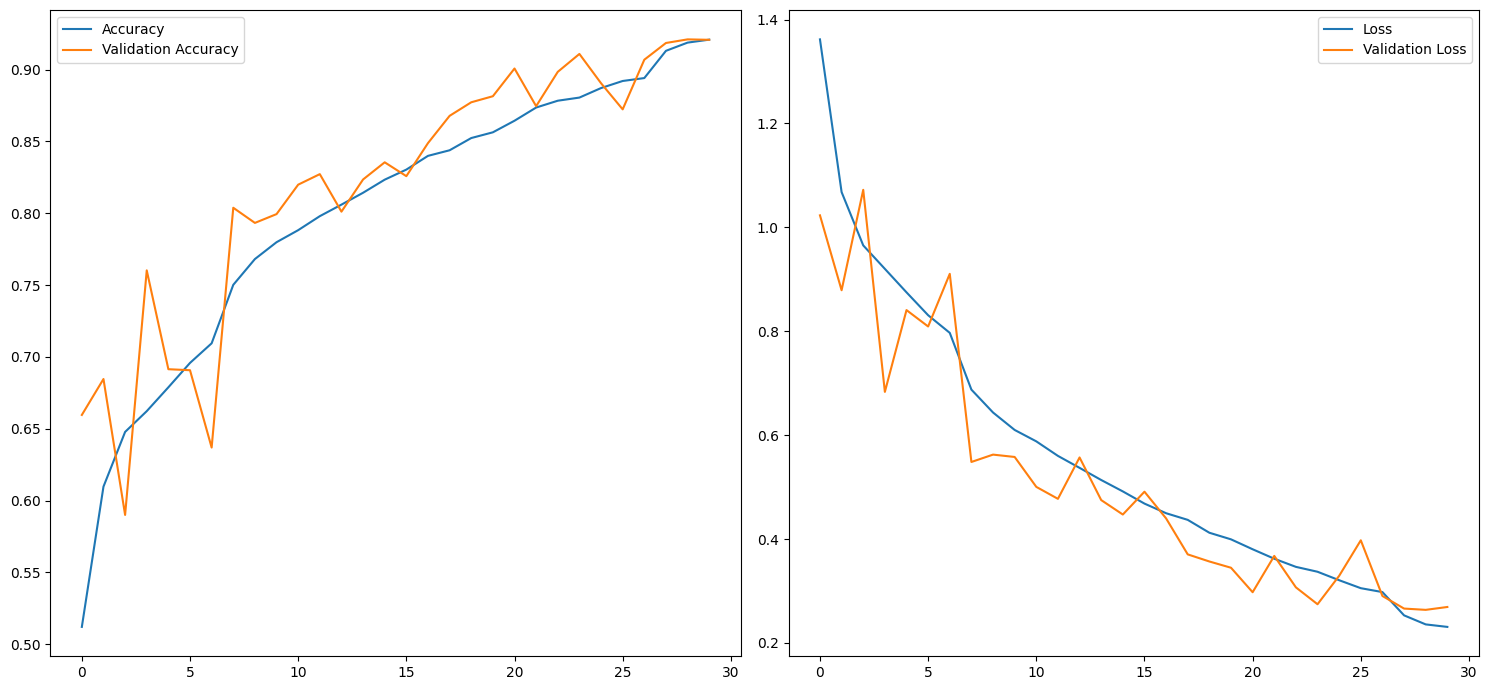

In [25]:
fig,axes=plt.subplots(1,2,figsize=(15,7))

axes[0].plot(history.history['accuracy'],label='Accuracy')
axes[0].plot(history.history['val_accuracy'],label='Validation Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],label='Loss')
axes[1].plot(history.history['val_loss'],label='Validation Loss')
axes[1].legend()


fig.tight_layout()
fig.show()

In [26]:
model.save("/kaggle/working/RESnet50.keras")
print("Model saved successfully!")

Model saved successfully!


In [27]:
model.save("/kaggle/working/RESnet.h5")
print("Model saved as H5 successfully!")

Model saved as H5 successfully!


In [28]:
from tensorflow.keras.layers import BatchNormalization

# Freeze everything first
for layer in foundational_model.layers:
    layer.trainable = False

# Unfreeze only the last 50 layers
for layer in foundational_model.layers[-50:]:
    if not isinstance(layer, BatchNormalization):
        layer.trainable = True

print("Trainable layers:",
      sum([layer.trainable for layer in foundational_model.layers]))

Trainable layers: 35


In [29]:
from tensorflow.keras.optimizers import AdamW

optimizer = AdamW(
    learning_rate=1e-5,
    weight_decay=1e-4
)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [30]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_resnet50.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

In [31]:
history_ft1 = model.fit(
    train_data,
    validation_data=validation,
    epochs=45,
    initial_epoch=30,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ]
)

Epoch 31/45
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.9243 - loss: 0.2248
Epoch 31: val_accuracy improved from None to 0.91984, saving model to best_resnet50.keras

Epoch 31: finished saving model to best_resnet50.keras
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 367s 285ms/step - accuracy: 0.9259 - loss: 0.2188 - val_accuracy: 0.9198 - val_loss: 0.2688 - learning_rate: 1.0000e-05
Epoch 32/45
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.9229 - loss: 0.2248
Epoch 32: val_accuracy improved from 0.91984 to 0.92767, saving model to best_resnet50.keras

Epoch 32: finished saving model to best_resnet50.keras
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 353s 283ms/step - accuracy: 0.9257 - loss: 0.2159 - val_accuracy: 0.9277 - val_loss: 0.2450 - learning_rate: 1.0000e-05
Epoch 33/45
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.9277 - loss: 0.2167
Epoch 33: val_accuracy did not improve from 0.92767
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 351s 282ms/step - accuracy: 0.9297 - loss: 0.21

In [32]:
# Evaluate the model
loss, acc = model.evaluate(validation, verbose=1)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {acc*100:.2f}%")

312/312 ━━━━━━━━━━━━━━━━━━━━ 52s 166ms/step - accuracy: 0.9277 - loss: 0.2450
Validation Loss: 0.2450
Validation Accuracy: 92.77%


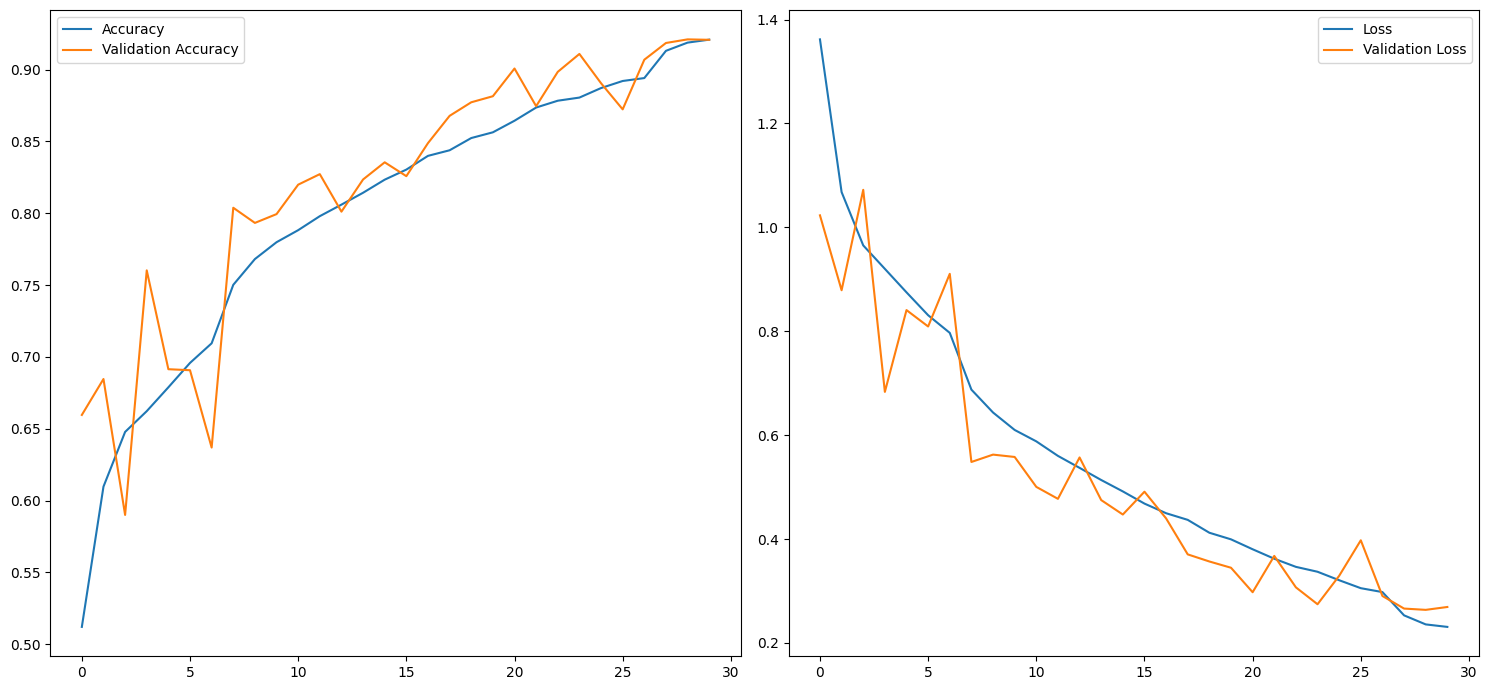

In [39]:
fig,axes=plt.subplots(1,2,figsize=(15,7))

axes[0].plot(history.history['accuracy'],label='Accuracy')
axes[0].plot(history.history['val_accuracy'],label='Validation Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],label='Loss')
axes[1].plot(history.history['val_loss'],label='Validation Loss')
axes[1].legend()


fig.tight_layout()
fig.show()